In [1]:
import json
import sqlite3
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
connection = sqlite3.connect("data/all_hiski_records.sqlite3")
cursor = connection.cursor()

In [3]:
query = """
    SELECT *
    FROM parish;
"""

cursor.execute(query)

parish_id_to_place = {
    row[0]: {
        "province": row[1],
        "name": row[2],
        "namese": row[3],
        "xpos": row[4],
        "ypos": row[5],
        "lon": row[6],
        "lat": row[7],
        "history": row[8],
    }
    for row in cursor.fetchall()
}

## Total number of parishes in database

In [ ]:
query = """
    SELECT parish_id, COUNT(parish_id)
    FROM immigrated
    GROUP BY parish_id;
"""

cursor.execute(query)

immigration_parish_event_counts = cursor.fetchall()
immigration_parish_event_counts = pd.DataFrame(
    immigration_parish_event_counts, columns=["parish_id", "count"]
)


query = """
    SELECT parish_id, COUNT(parish_id)
    FROM emigrated
    GROUP BY parish_id;
"""

cursor.execute(query)

emigration_parish_event_counts = cursor.fetchall()
emigration_parish_event_counts = pd.DataFrame(
    emigration_parish_event_counts, columns=["parish_id", "count"]
)

In [ ]:
immigration_parish_event_counts["name"] = immigration_parish_event_counts[
    "parish_id"
].map(lambda p_id: parish_id_to_place.get(p_id, {"name": "unknown"})["name"])
emigration_parish_event_counts["name"] = emigration_parish_event_counts[
    "parish_id"
].map(lambda p_id: parish_id_to_place.get(p_id, {"name": "unknown"})["name"])

In [140]:
print(
    "Number of",
    f" - parishes in parishes-table: {len(
        parish_id_to_place
    )}",
    f" - parishes not in parishes-table: {
        len(
            set(immigration_parish_event_counts["parish_id"].unique()).union(
                set(emigration_parish_event_counts["parish_id"].unique())
            ).difference(set(parish_id_to_place.keys())
        )
    )}",
    f" - parishes in immigrated-table: {len(
        immigration_parish_event_counts["parish_id"].unique()
    )}",
    f" - parishes in emigrated-table: {len(
        emigration_parish_event_counts["parish_id"].unique()
    )}",
    f" - parishes not in common between immigrated-table and emigrated-table: {
        len(set(immigration_parish_event_counts["parish_id"].unique()).symmetric_difference(
            set(emigration_parish_event_counts["parish_id"].unique()
        ))
    )}",
    sep="\n"
)

Number of
 - parishes in parishes-table: 522
 - parishes not in parishes-table: 1
 - parishes in immigrated-table: 166
 - parishes in emigrated-table: 166
 - parishes not in common between immigrated-table and emigrated-table: 22


## Distribution of events between parishes in database

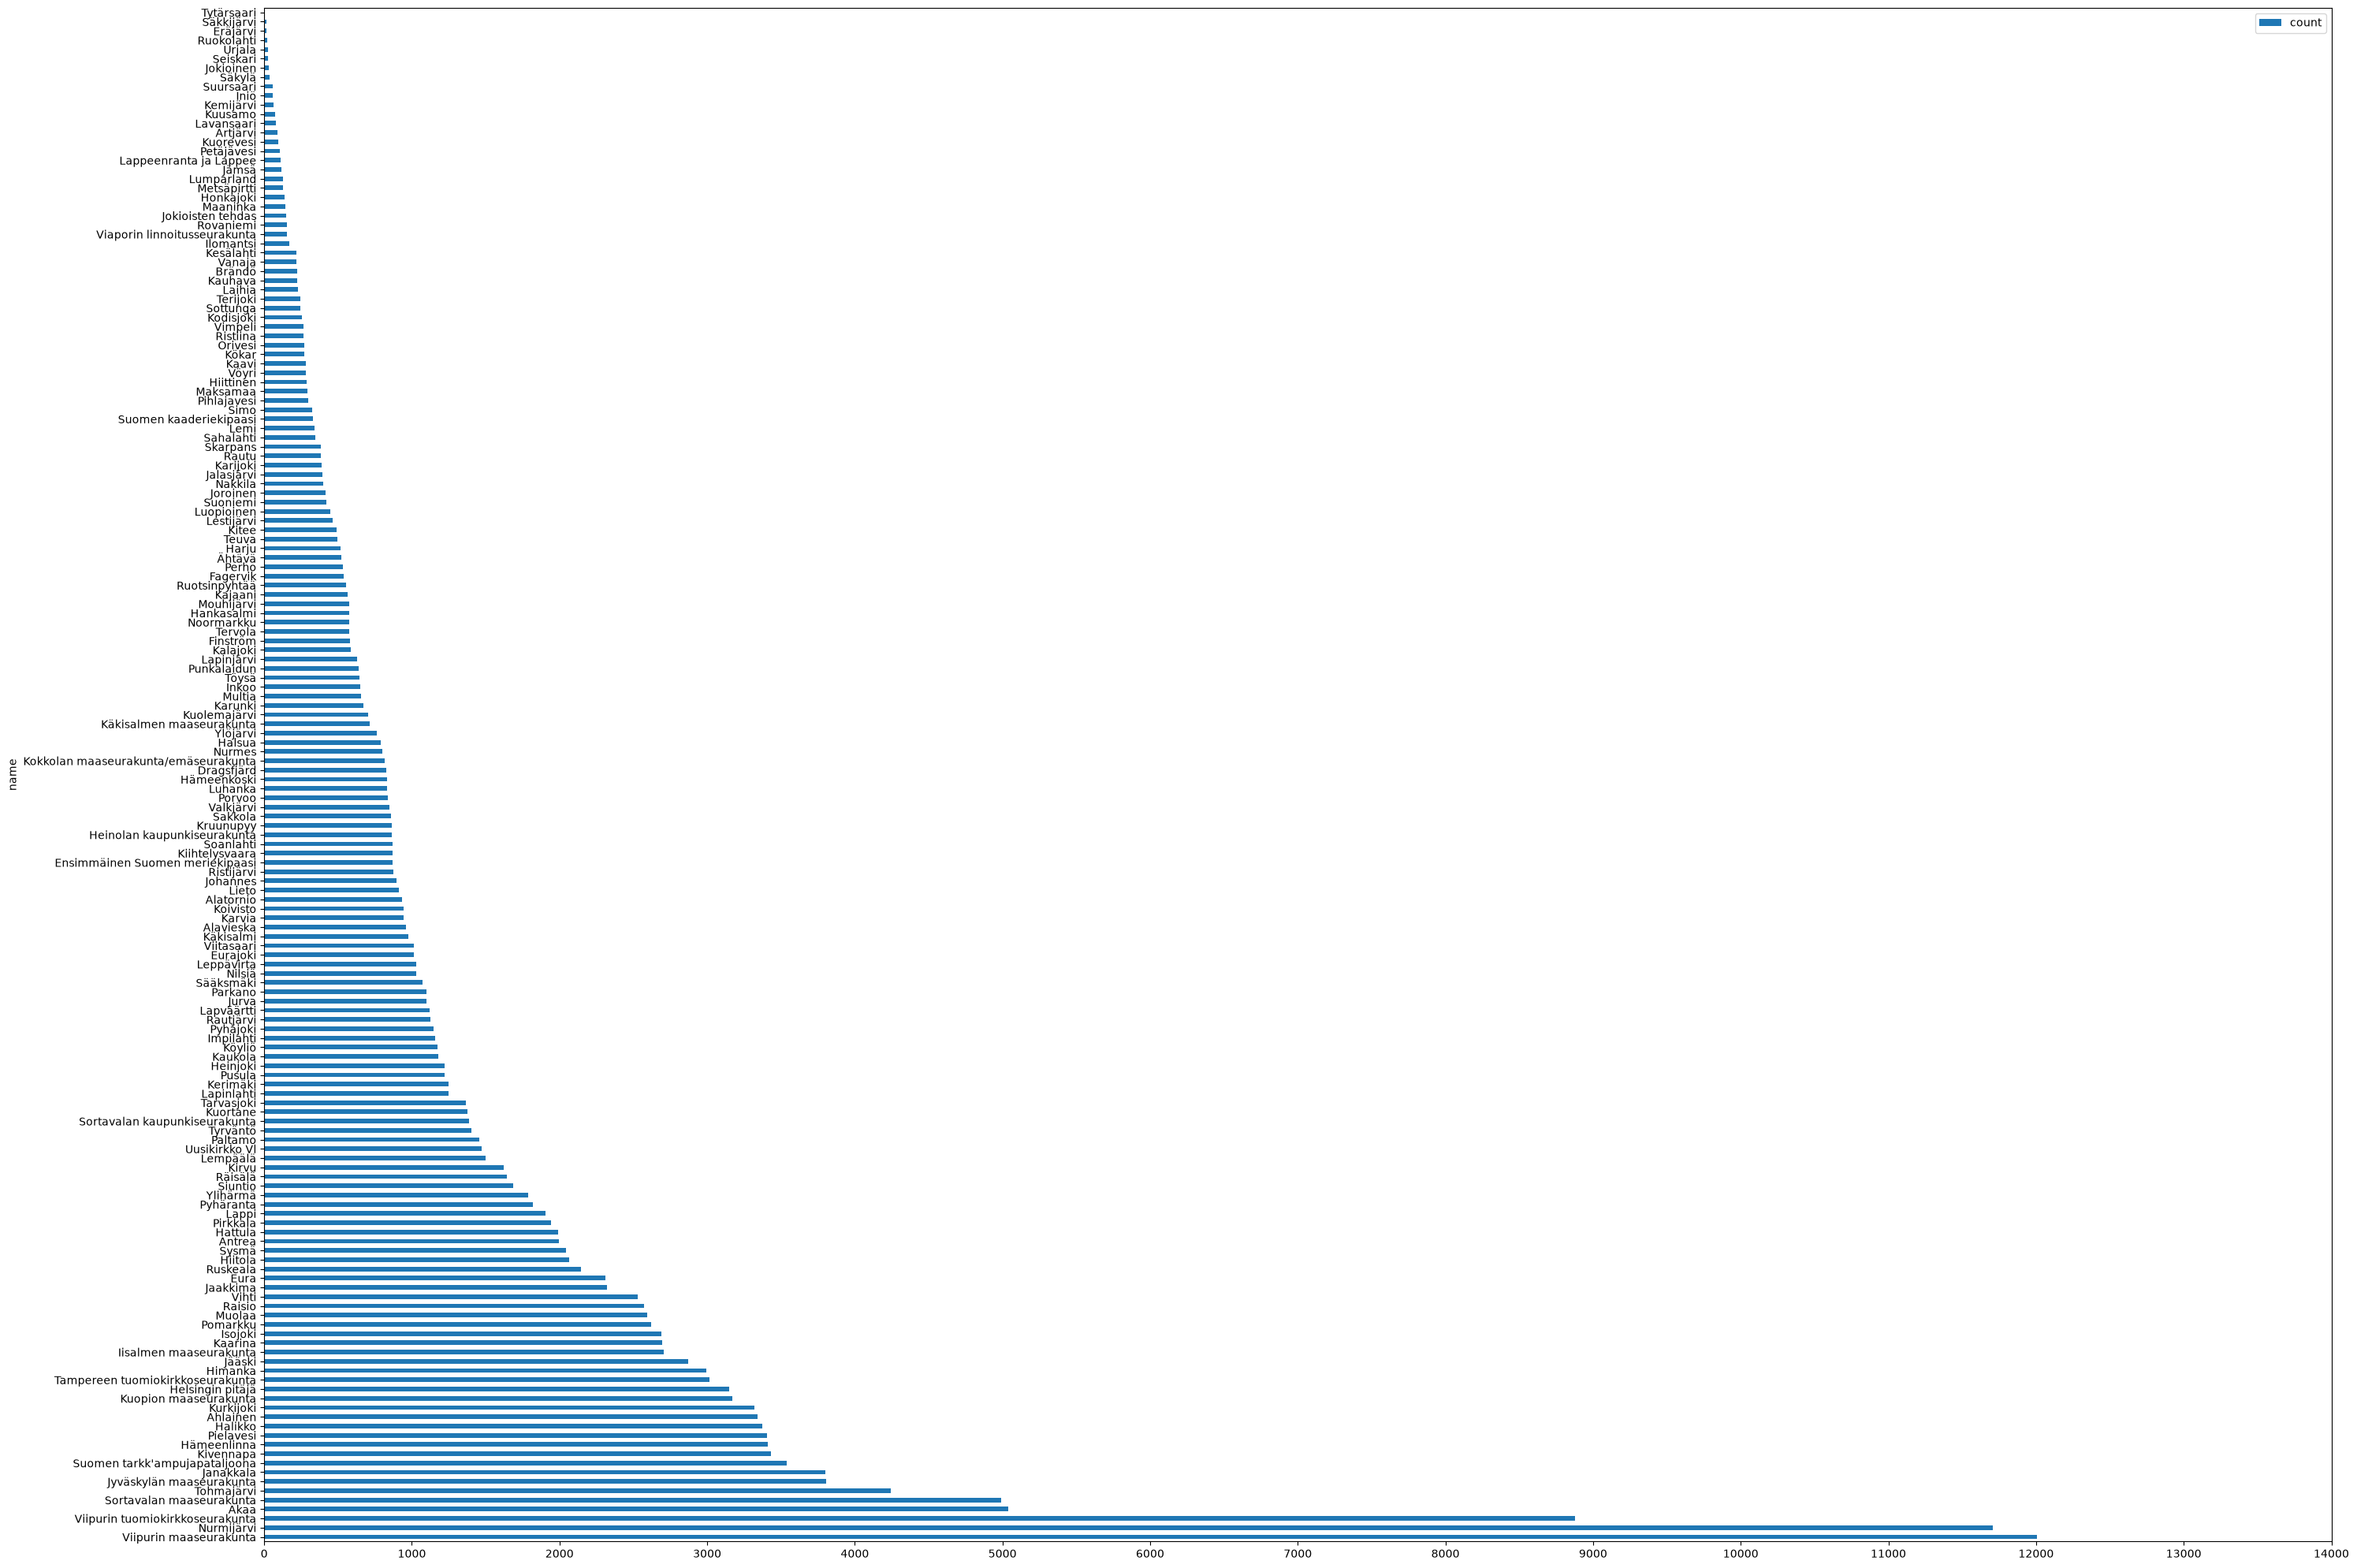

In [130]:
fig, ax = plt.subplots(1, 1, figsize=(30, 20))
immigration_parish_event_counts.sort_values(
    "count", ascending=False
).plot.barh(y="count", x="name", ax=ax)
ax.set_xticks(range(0, 15000, 1000), range(0, 15000, 1000))
fig.tight_layout()

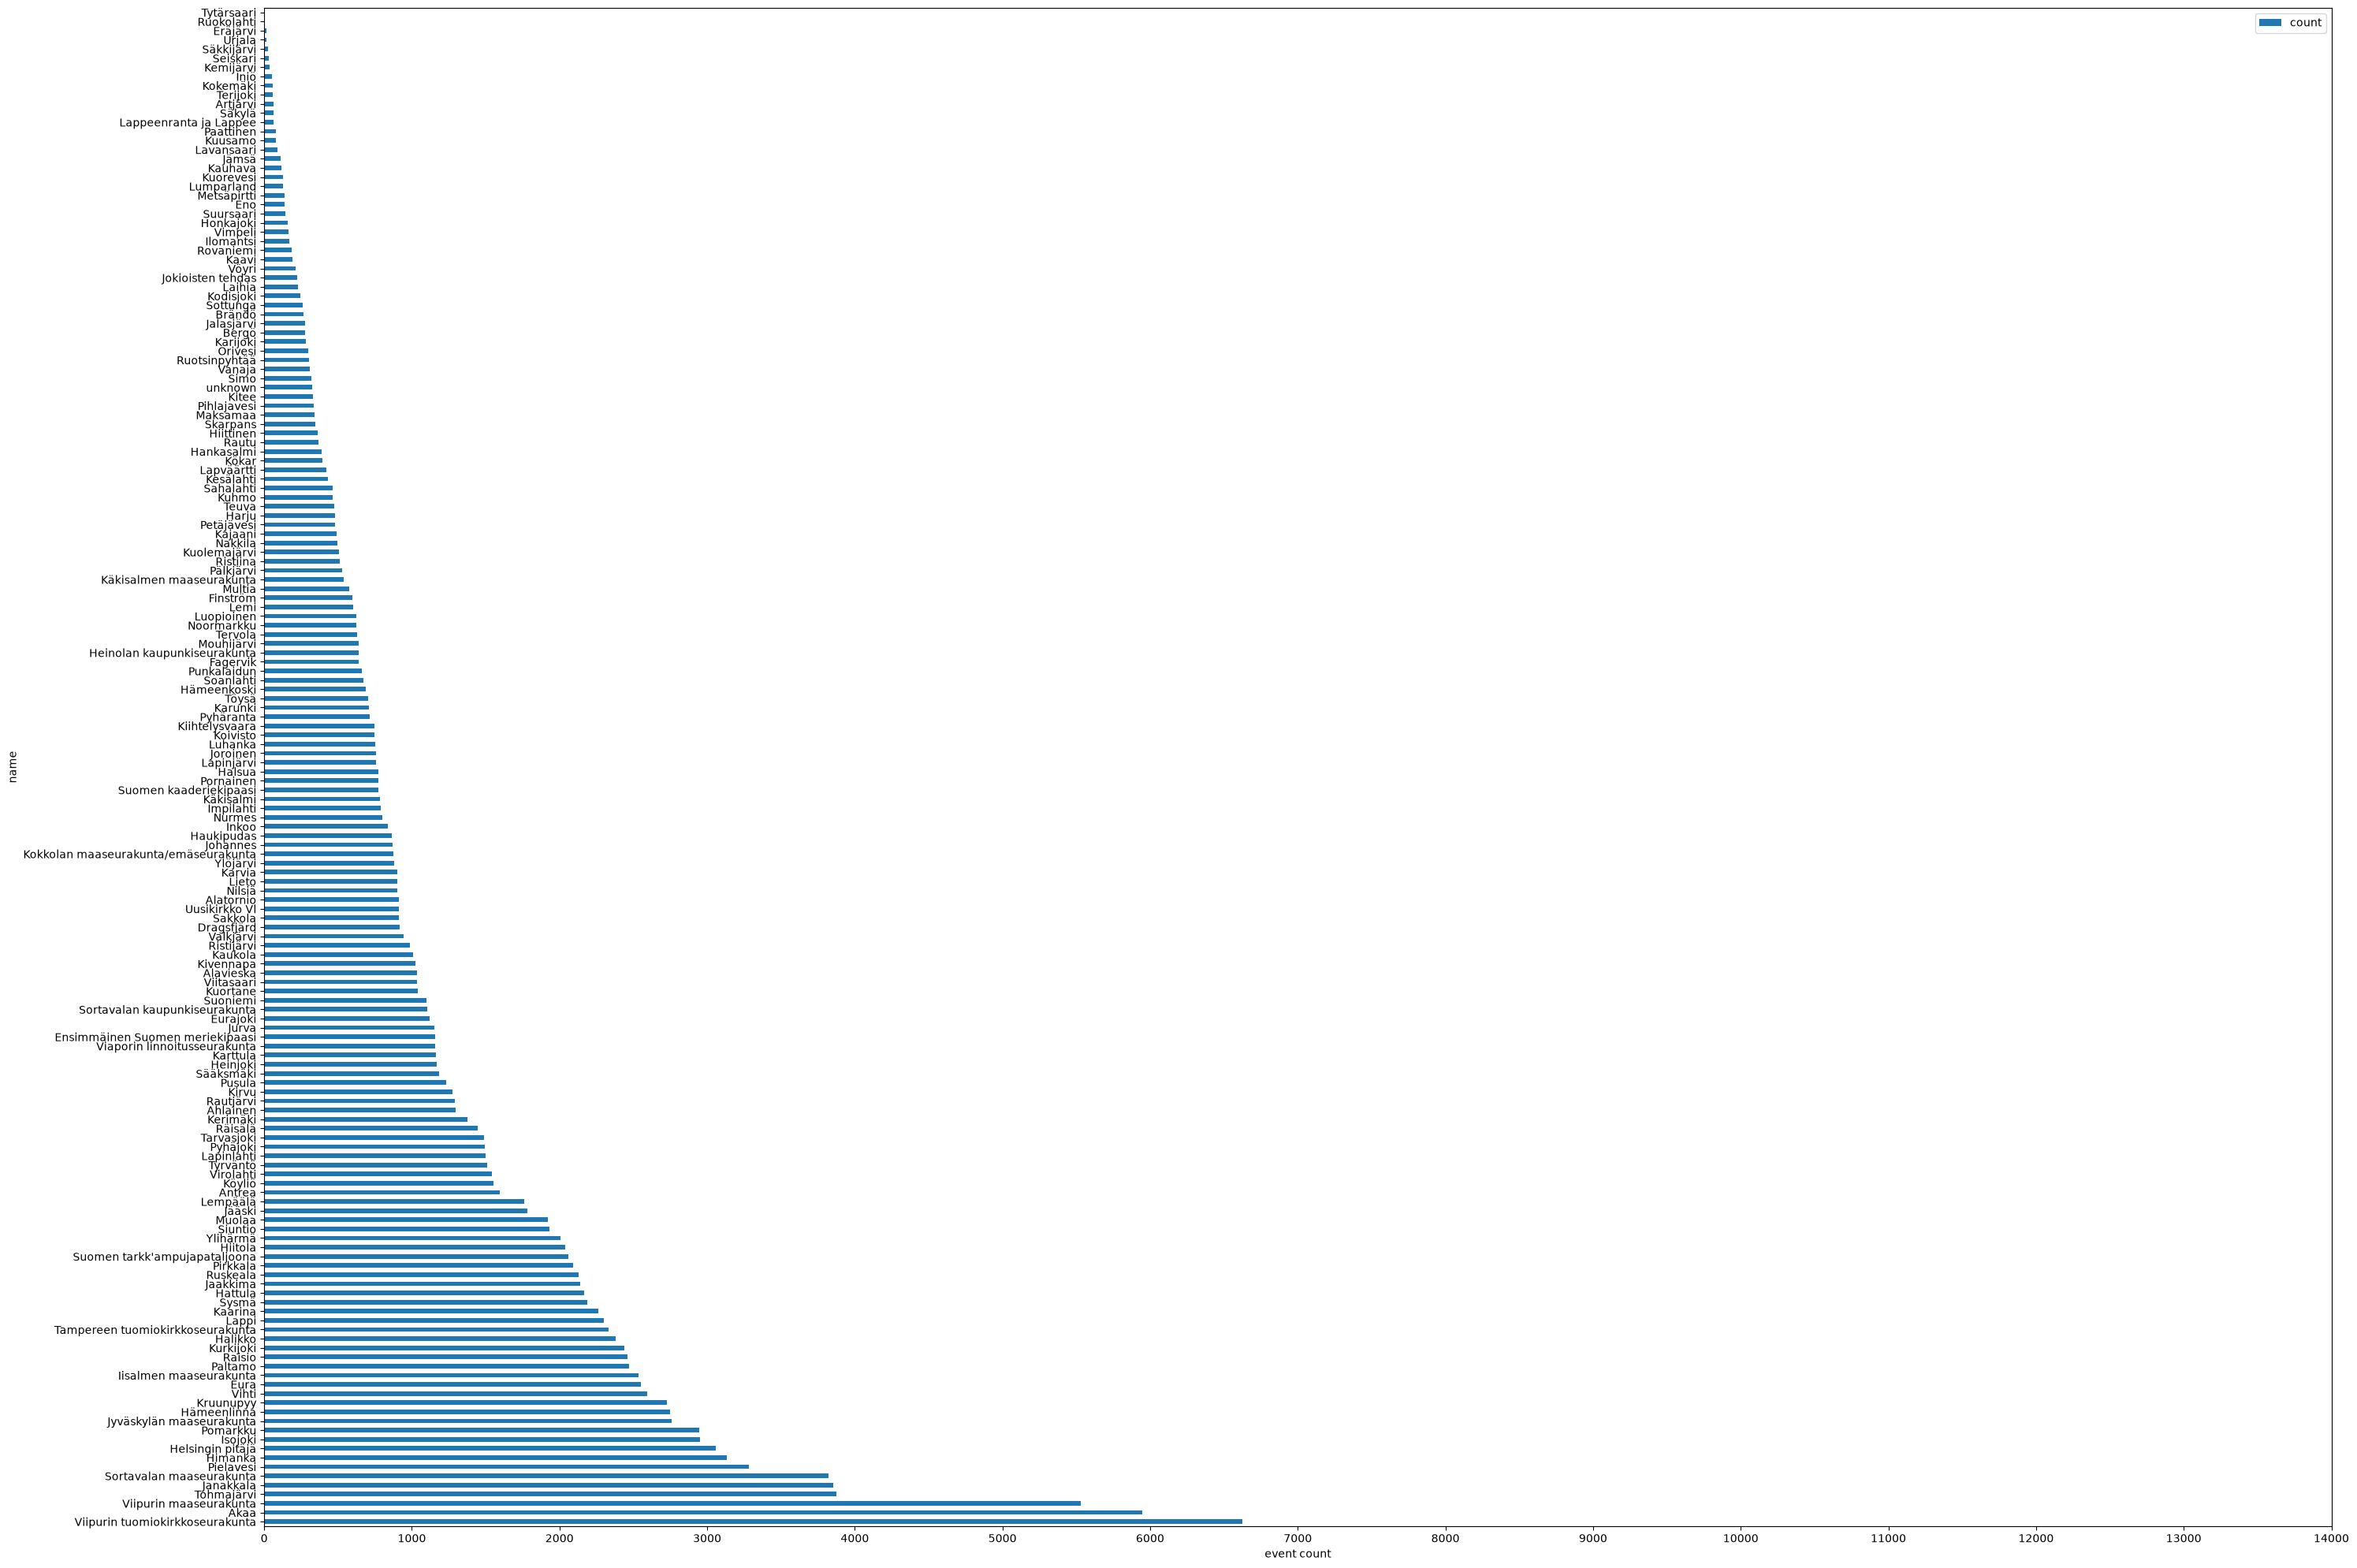

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(30, 20))
emigration_parish_event_counts.sort_values(
    "count", ascending=False
).plot.barh(y="count", x="name", ax=ax)
ax.set_xticks(range(0, 15000, 1000), range(0, 15000, 1000))
fig.tight_layout()

### Top 25 parishes

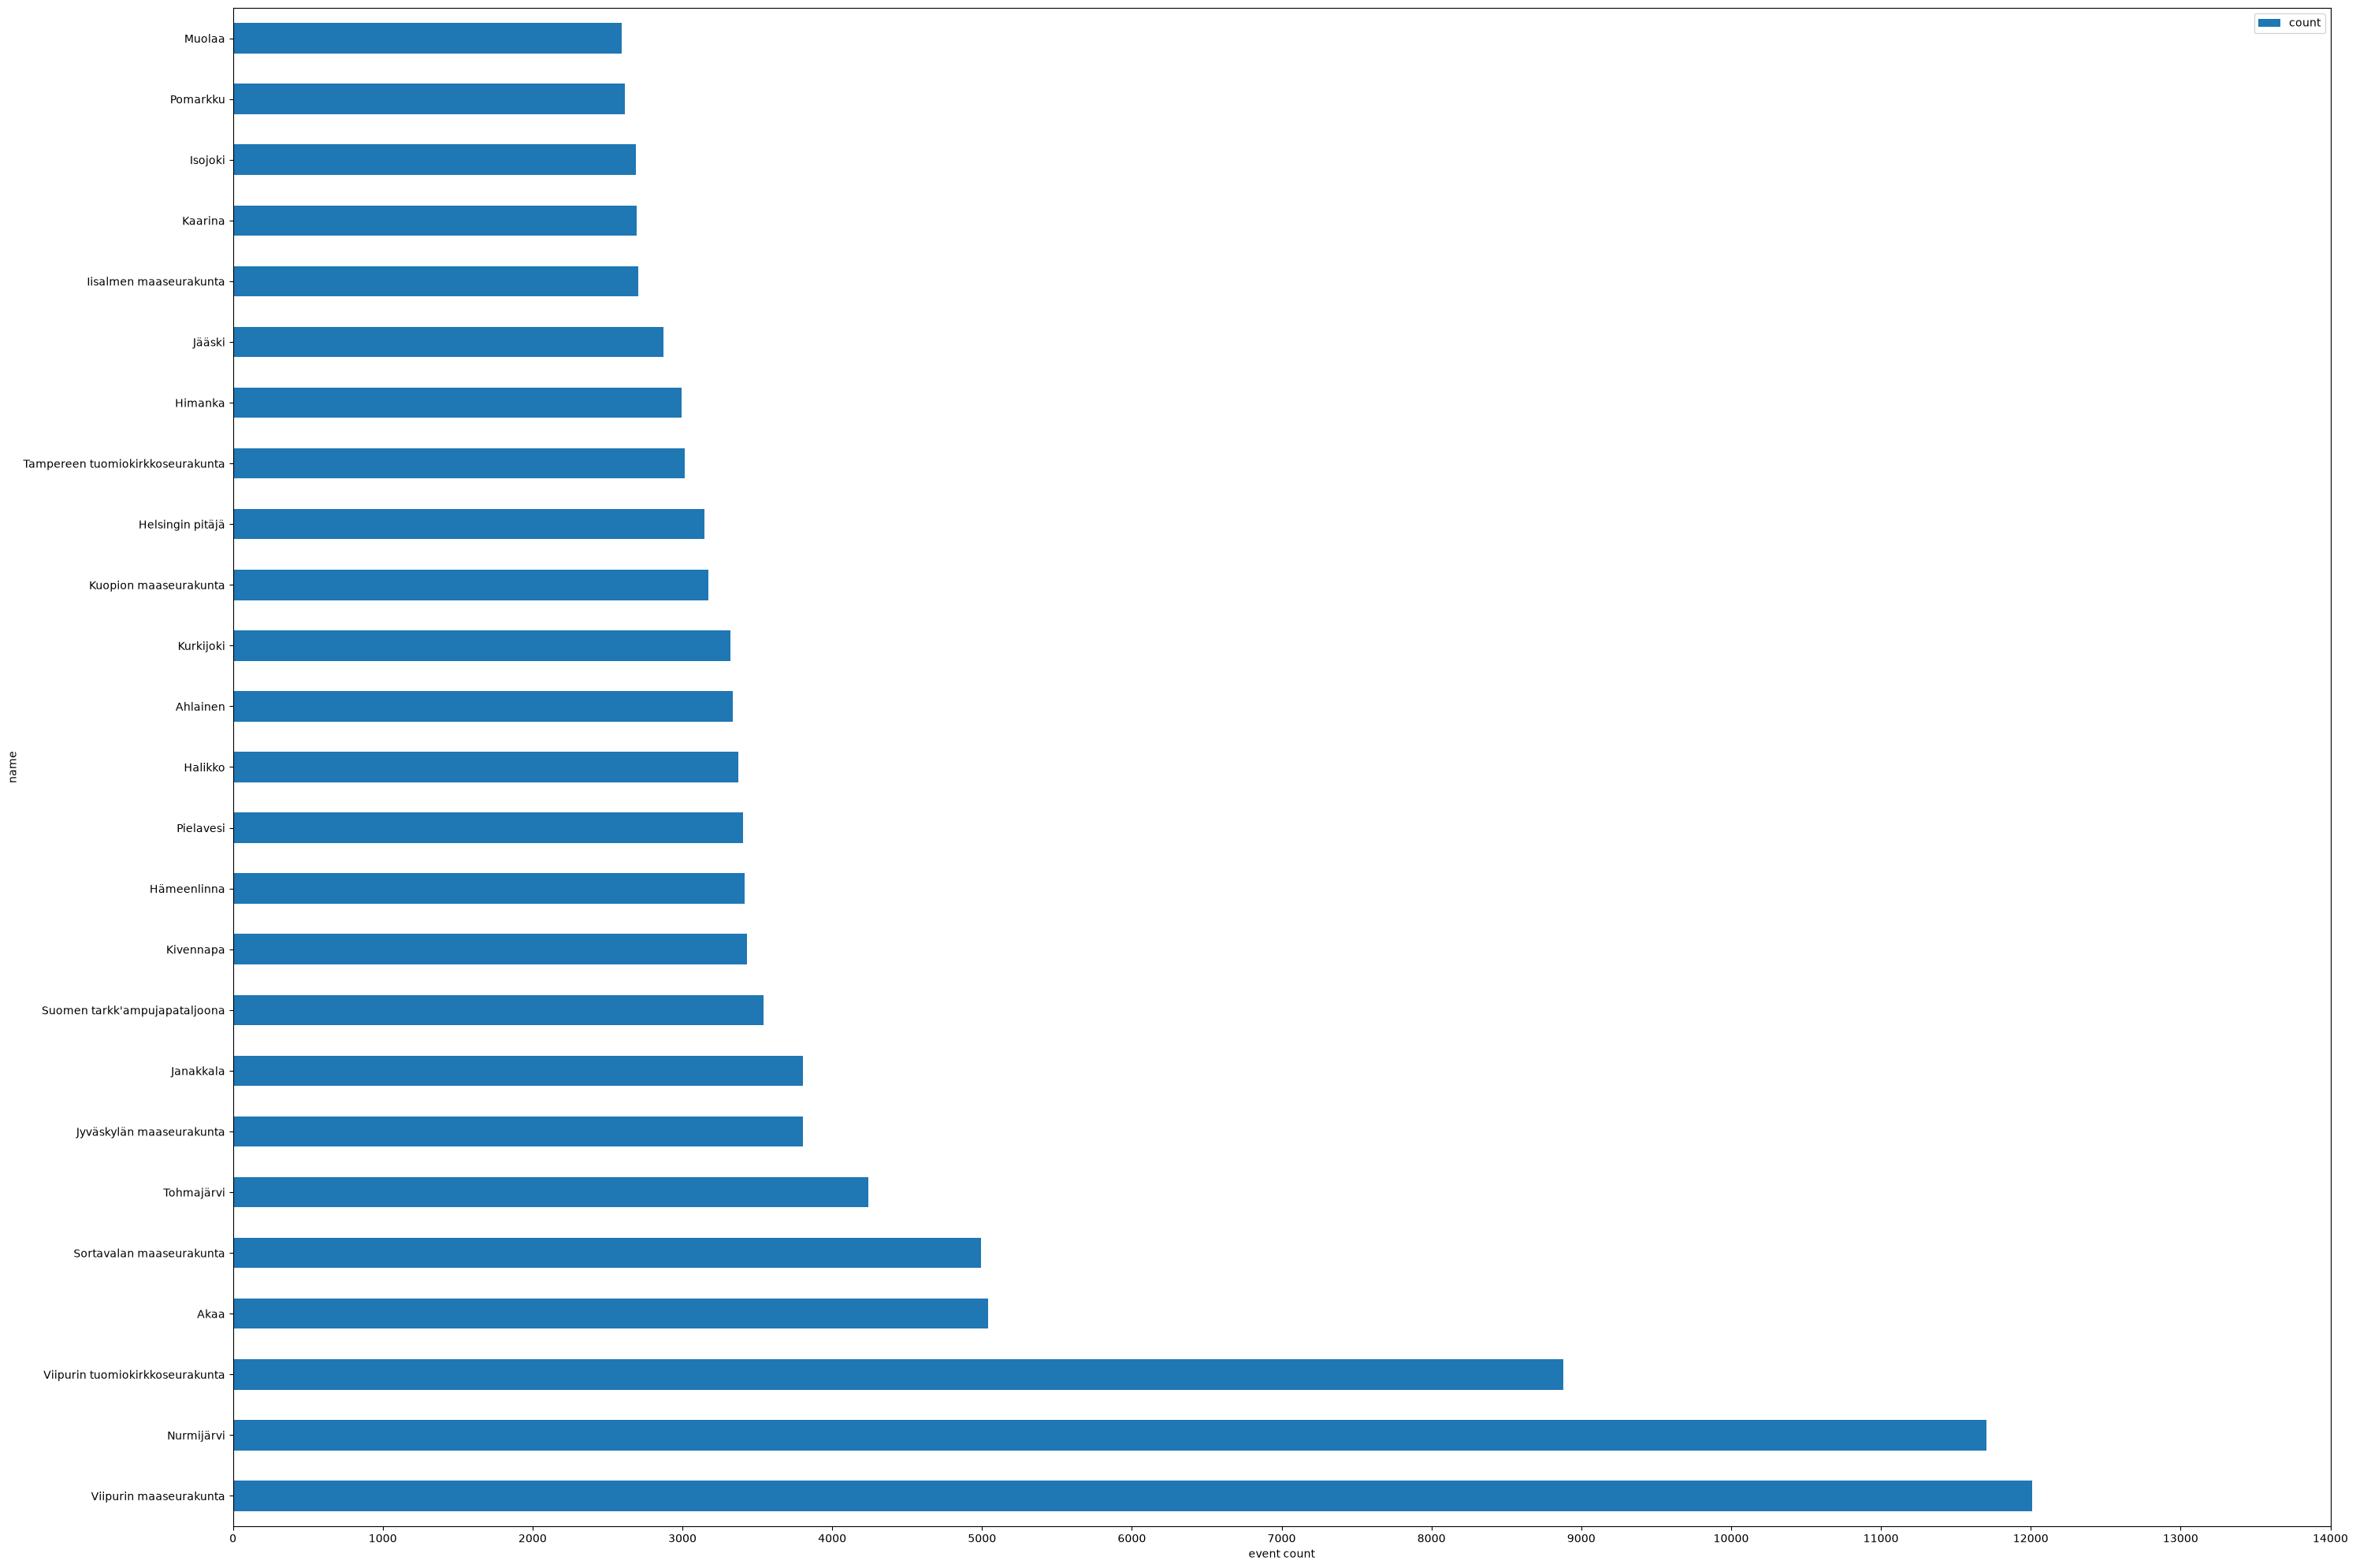

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(30, 20))
immigration_parish_event_counts.sort_values(
    "count", ascending=False
)[:25].plot.barh(y="count", x="name", ax=ax)
ax.set_xticks(range(0, 15000, 1000), range(0, 15000, 1000))
fig.tight_layout()

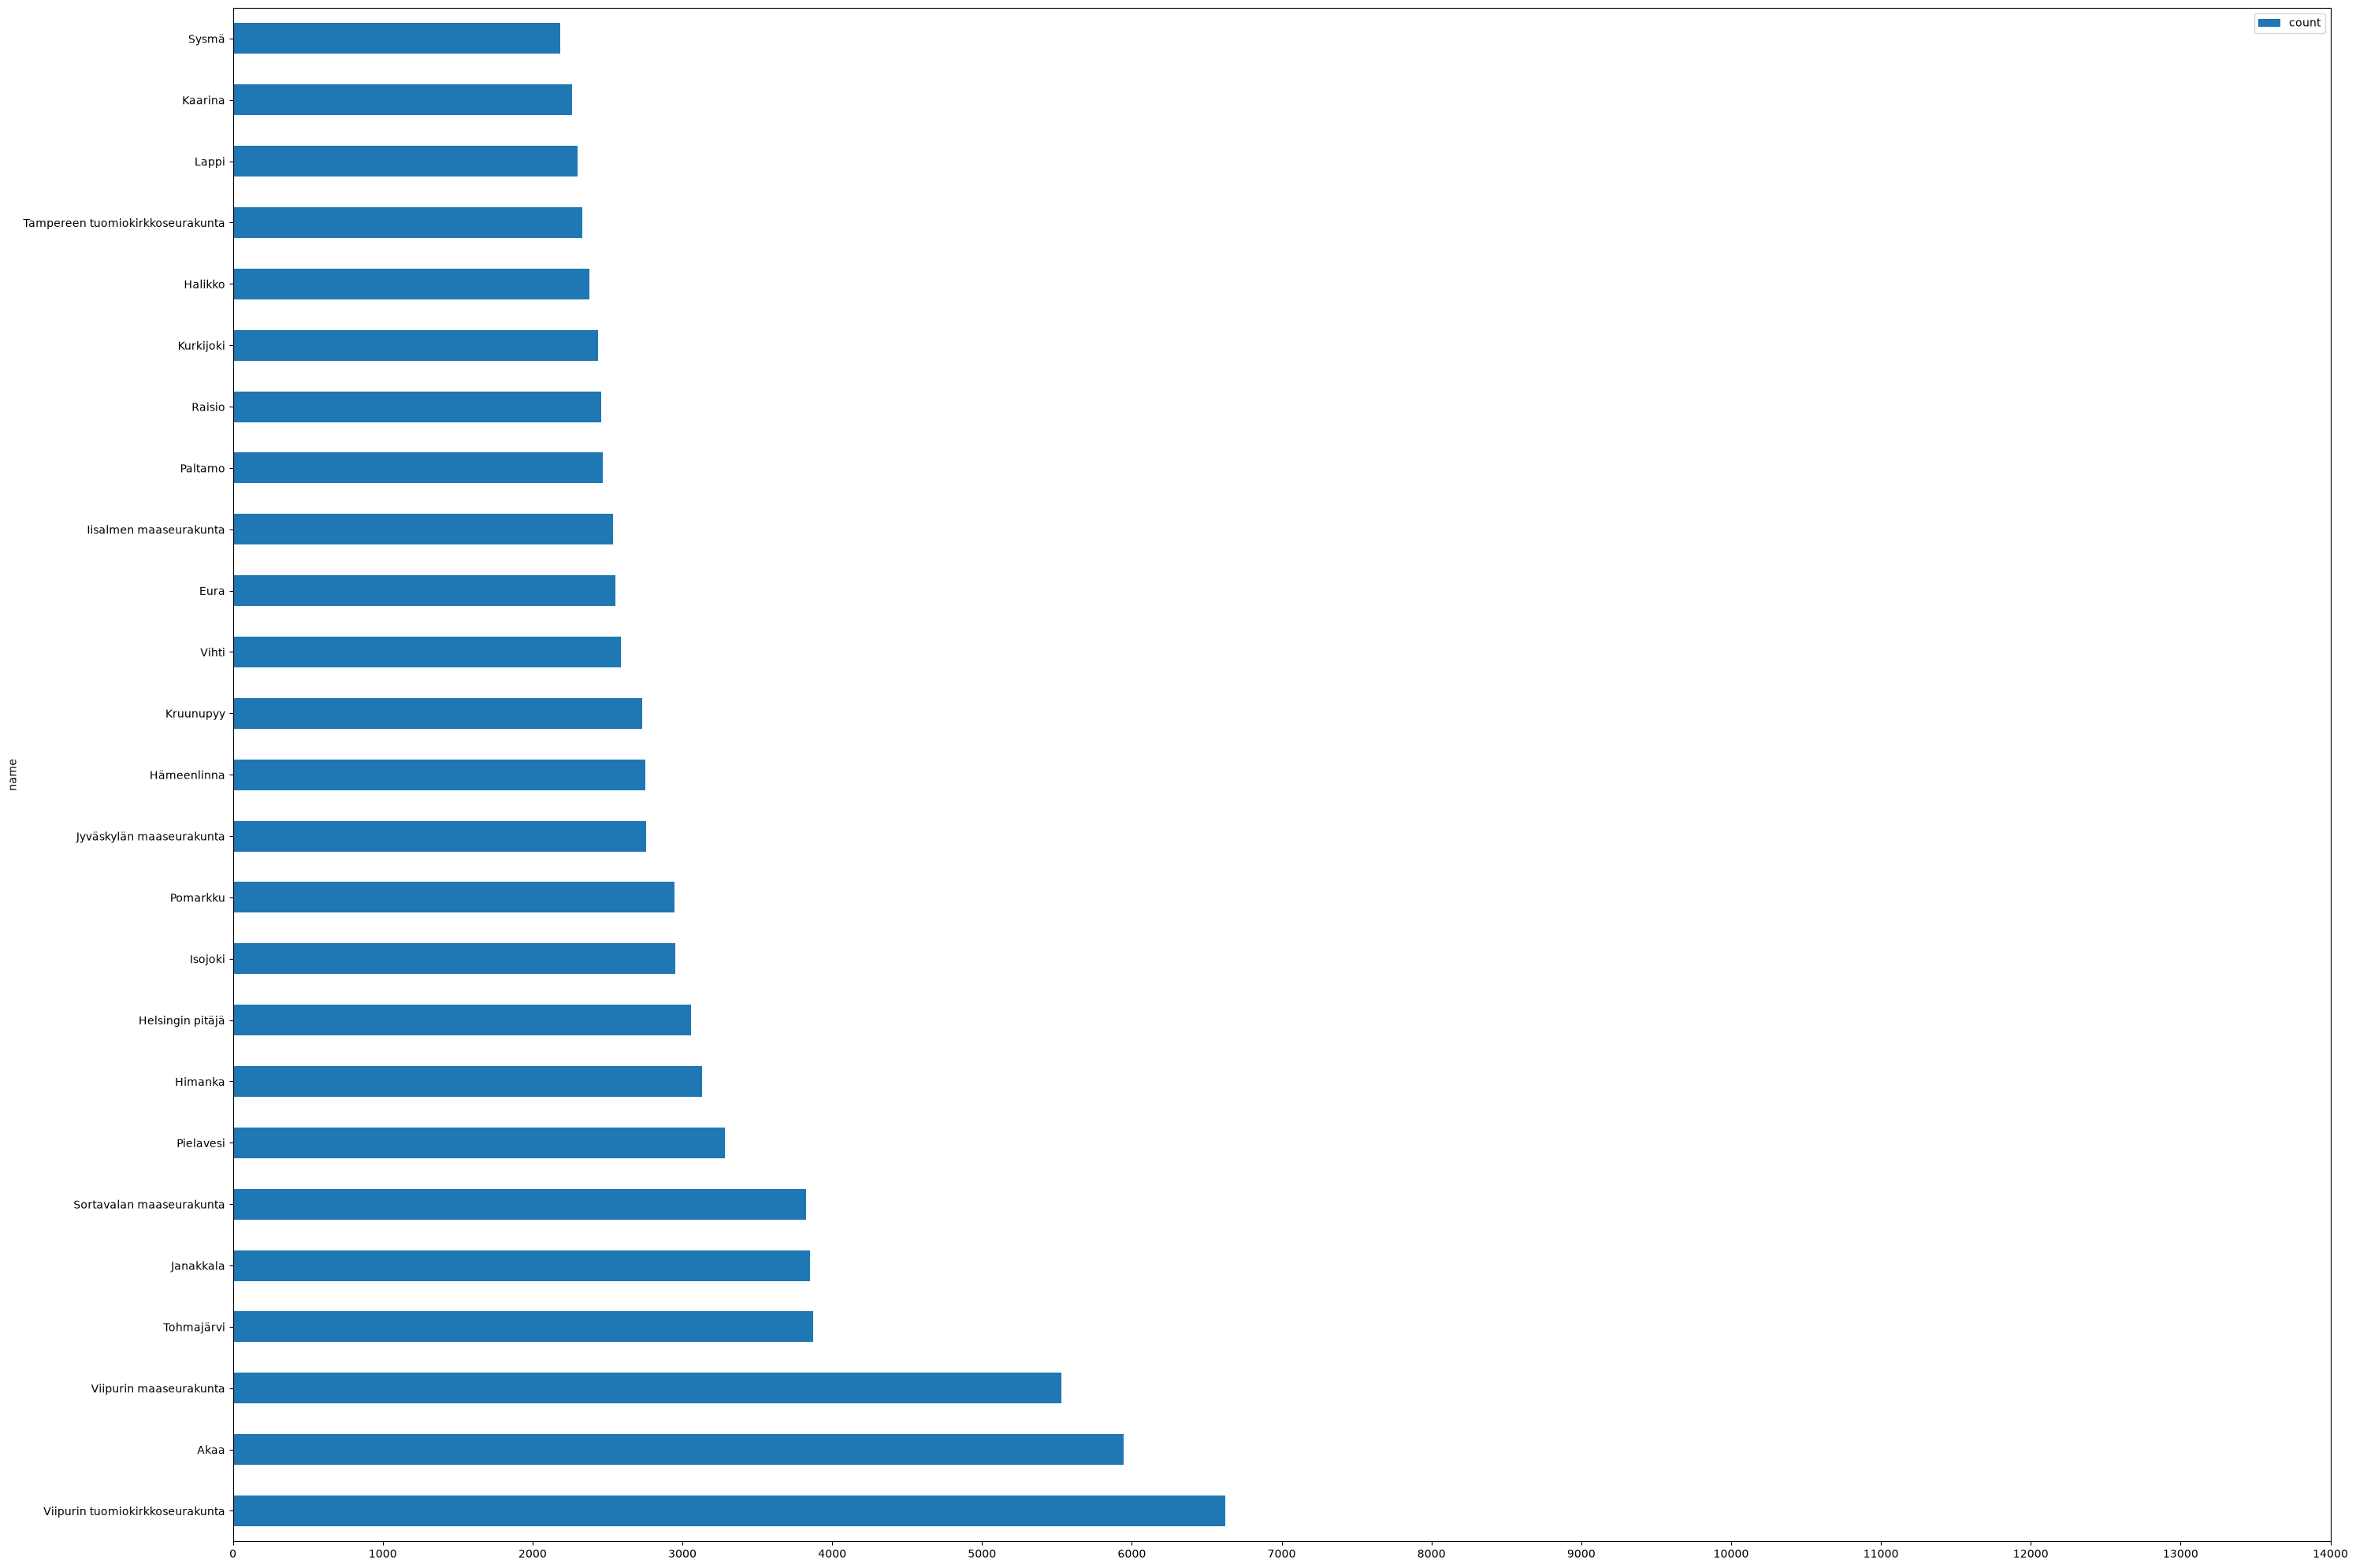

In [135]:
fig, ax = plt.subplots(1, 1, figsize=(30, 20))
emigration_parish_event_counts.sort_values(
    "count", ascending=False
)[:25].plot.barh(y="count", x="name", ax=ax)
ax.set_xticks(range(0, 15000, 1000), range(0, 15000, 1000))
fig.tight_layout()

## Parish events on map

In [113]:
immigration_parish_e_counts_with_coordinates = (
    immigration_parish_event_counts.copy()
)
immigration_parish_e_counts_with_coordinates["lon"] = (
    immigration_parish_e_counts_with_coordinates["parish_id"].map(
        lambda x: parish_id_to_place.get(x, {"lon": None})["lon"]
    )
)
immigration_parish_e_counts_with_coordinates["lat"] = (
    immigration_parish_e_counts_with_coordinates["parish_id"].map(
        lambda x: parish_id_to_place.get(x, {"lat": None})["lat"]
    )
)


emigration_parish_e_counts_with_coordinates = (
    emigration_parish_event_counts.copy()
)
emigration_parish_e_counts_with_coordinates["lon"] = (
    emigration_parish_e_counts_with_coordinates["parish_id"].map(
        lambda x: parish_id_to_place.get(x, {"lon": None})["lon"]
    )
)
emigration_parish_e_counts_with_coordinates["lat"] = (
    emigration_parish_e_counts_with_coordinates["parish_id"].map(
        lambda x: parish_id_to_place.get(x, {"lat": None})["lat"]
    )
)

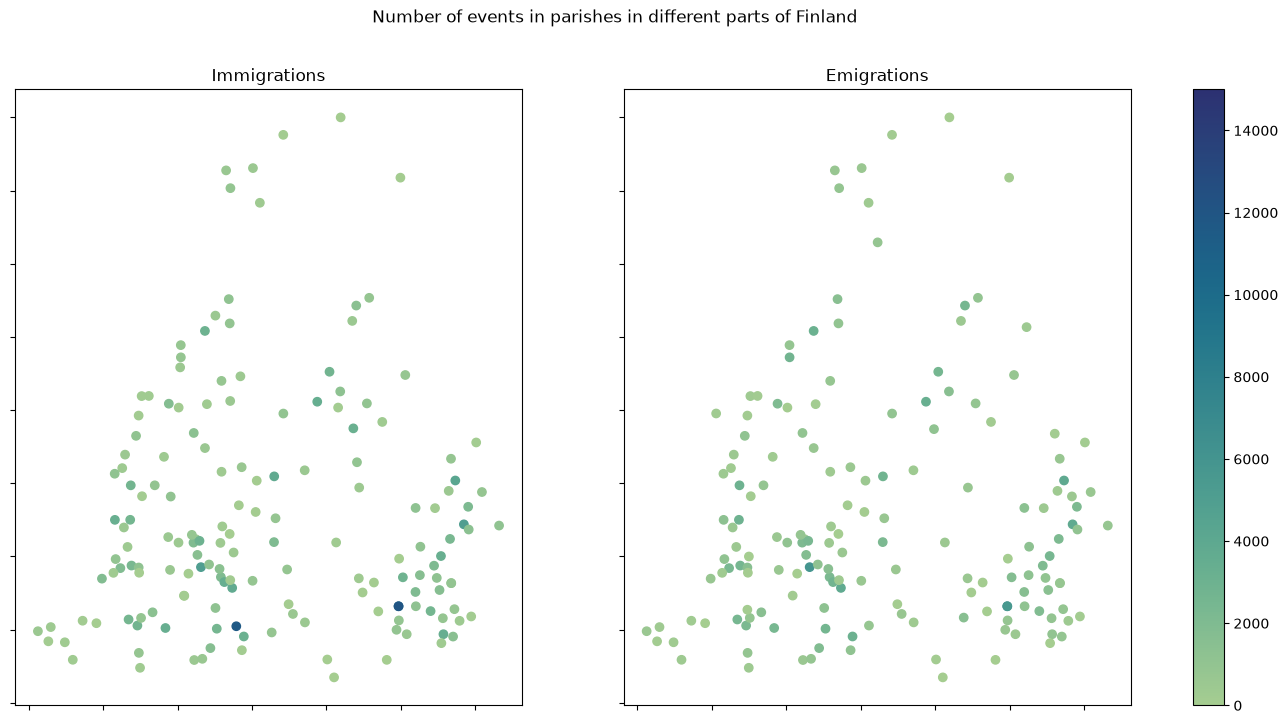

In [136]:
fig, axs = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle("Number of events in parishes in different parts of Finland")
axs[0].scatter(
    x=immigration_parish_e_counts_with_coordinates["lon"],
    y=immigration_parish_e_counts_with_coordinates["lat"],
    c=immigration_parish_e_counts_with_coordinates["count"],
    cmap=sns.cm.crest,
    vmin=0, vmax=15000
)
axs[0].set_yticklabels([])
axs[0].set_xticklabels([])
axs[0].set_title("Immigrations")

scatter = axs[1].scatter(
    x=emigration_parish_e_counts_with_coordinates["lon"],
    y=emigration_parish_e_counts_with_coordinates["lat"],
    c=emigration_parish_e_counts_with_coordinates["count"],
    cmap=sns.cm.crest,
    vmin=0, vmax=15000
)
axs[1].set_yticklabels([])
axs[1].set_xticklabels([])
axs[1].set_title("Emigrations")
fig.colorbar(scatter, ax=axs, fraction=0.05)